In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
import torch
print("CUDA available:", torch.cuda.is_available())


name, memory.total [MiB]
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB
CUDA available: True


In [2]:
# Clone the official SwinIR repo
!git clone https://github.com/JingyunLiang/SwinIR.git /kaggle/working/SwinIR
%cd /kaggle/working/SwinIR

# Core deps
!pip install -q timm einops rasterio scikit-image sentinelhub tifffile opencv-python-headless


Cloning into '/kaggle/working/SwinIR'...
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 333 (delta 6), reused 2 (delta 2), pack-reused 323 (from 2)
Receiving objects: 100% (333/333), 29.84 MiB | 37.67 MiB/s, done.
Resolving deltas: 100% (119/119), done.
/kaggle/working/SwinIR
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.4/240.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 16.4 MB/s eta 0:00:00


In [3]:
import os
os.makedirs('/kaggle/working/SwinIR/model_zoo/swinir', exist_ok=True)

# Classical SR x4, medium size — good balance of quality/speed on a T4
!wget -q -O /kaggle/working/SwinIR/model_zoo/swinir/001_classicalSR_DF2K_s64w8_SwinIR-M_x4.pth \
  https://github.com/JingyunLiang/SwinIR/releases/download/v0.0/001_classicalSR_DF2K_s64w8_SwinIR-M_x4.pth

print("Downloaded baseline weights.")


Downloaded baseline weights.


In [4]:
# Load SEN2VENUS directly via tacoreader — no manual browsing/site-picking needed.
# Covers 29 locations worldwide, same-day Sentinel-2 (10m) <-> VENUS (5m) pairs.
!pip install -q tacoreader rasterio

import tacoreader.v1 as tacoreader
dataset = tacoreader.load("tacofoundation:sen2venus")

# Grab a slice of pairs for a fast prototype run (the full dataset has ~130,000 pairs).
N_PAIRS = 1000
pairs = []
for i in range(0, N_PAIRS):
    row = dataset.read(i)
    lr_path, hr_path = row.read(0), row.read(1)
    pairs.append((lr_path, hr_path))
    if (i + 1) % 20 == 0:
        print(f"Loaded {i + 1}/{N_PAIRS} pairs...")

print(f"Done — loaded {len(pairs)} HR/LR pairs total")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 6.6 MB/s eta 0:00:00
Loaded 20/1000 pairs...
Loaded 40/1000 pairs...
Loaded 60/1000 pairs...
Loaded 80/1000 pairs...
Loaded 100/1000 pairs...
Loaded 120/1000 pairs...
Loaded 140/1000 pairs...
Loaded 160/1000 pairs...
Loaded 180/1000 pairs...
Loaded 200/1000 pairs...
Loaded 220/1000 pairs...
Loaded 240/1000 pairs...
Loaded 260/1000 pairs...
Loaded 280/1000 pairs...
Loaded 300/1000 pairs...
Loaded 320/1000 pairs...
Loaded 340/1000 pairs...
Loaded 360/1000 pairs...
Loaded 380/1000 pairs...
Loaded 400/1000 pairs...
Loaded 420/1000 pairs...
Loaded 440/1000 pairs...
Loaded 460/1000 pairs...
Loaded 480/1000 pairs...
Loaded 500/1000 pairs...
Loaded 520/1000 pairs...
Loaded 540/1000 pairs...
Loaded 560/1000 pairs...
Loaded 580/1000 pairs...
Loaded 600/1000 pairs...
Loaded 620/1000 pairs

In [5]:
import rasterio
import numpy as np

all_percentiles = []
for i in range(50):  # check 50 samples for a reliable estimate
    lr_path, hr_path = pairs[i]
    with rasterio.open(lr_path) as src:
        arr = src.read([1,2,3]).astype(np.float32)
    all_percentiles.append(np.percentile(arr, 99))

print(f"Median of 99th percentiles across 50 samples: {np.median(all_percentiles):.2f}")
print(f"Max seen across samples: {np.max(all_percentiles):.2f}")
print(f"Min seen across samples: {np.min(all_percentiles):.2f}")

Median of 99th percentiles across 50 samples: 1126.00
Max seen across samples: 2137.00
Min seen across samples: 401.49


In [6]:
import numpy as np
import rasterio
from pathlib import Path

SCALE = 2          # set to match your actual HR:LR ratio (e.g. 2 for 10m->5m, 4 for 10m->2.5m)
LR_PATCH = 48       # LR patch size in pixels
HR_PATCH = LR_PATCH * SCALE

def read_bands(path, bands=(1,2,3), fixed_max=1500.0):
    """Read RGB bands, normalize using a FIXED scale (not per-image max)."""
    with rasterio.open(path) as src:
        arr = src.read(bands).astype(np.float32)
    arr = np.clip(arr / fixed_max, 0, 1)   # consistent scale across ALL images
    return np.transpose(arr, (1, 2, 0))

def extract_patches(hr_img, lr_img, hr_patch, scale, stride=None):
    stride = stride or hr_patch
    lr_patch = hr_patch // scale
    pairs = []
    h, w, _ = lr_img.shape
    for y in range(0, h - lr_patch + 1, stride // scale):
        for x in range(0, w - lr_patch + 1, stride // scale):
            lr_crop = lr_img[y:y+lr_patch, x:x+lr_patch]
            hr_crop = hr_img[y*scale:y*scale+hr_patch, x*scale:x*scale+hr_patch]
            if lr_crop.shape[:2] == (lr_patch, lr_patch) and hr_crop.shape[:2] == (hr_patch, hr_patch):
                pairs.append((lr_crop, hr_crop))
    return pairs

print("Patch extraction helpers ready. Point read_bands() at your downloaded HR/LR GeoTIFFs.")


Patch extraction helpers ready. Point read_bands() at your downloaded HR/LR GeoTIFFs.


In [7]:
from tqdm import tqdm

hr_list = []
lr_list = []
skipped = 0

for lr_path, hr_path in tqdm(pairs, desc="Loading pairs"):
    try:
        lr_img = read_bands(lr_path)
        hr_img = read_bands(hr_path)
        lr_list.append(lr_img)
        hr_list.append(hr_img)
    except Exception as e:
        skipped += 1
        continue  # skip this pair and move to next one

print(f"\nLoaded {len(lr_list)} LR images and {len(hr_list)} HR images")
print(f"Skipped {skipped} pairs due to errors (broken/missing files)")
print("Example LR shape:", lr_list[0].shape)
print("Example HR shape:", hr_list[0].shape)

Loading pairs: 100%|██████████| 1000/1000 [31:57<00:00,  1.92s/it]


Loaded 1000 LR images and 1000 HR images
Skipped 0 pairs due to errors (broken/missing files)
Example LR shape: (128, 128, 3)
Example HR shape: (256, 256, 3)


In [8]:
from sklearn.model_selection import train_test_split

# Split at the IMAGE level (not patch level) — prevents leakage since
# patches from the same image would otherwise appear in both train and val
train_lr, val_lr, train_hr, val_hr = train_test_split(
    lr_list, hr_list, test_size=0.1, random_state=42
)

print(f"Train images: {len(train_lr)}, Validation images: {len(val_lr)}")

Train images: 900, Validation images: 100


In [9]:
all_patches = []

for lr_img, hr_img in zip(train_lr, train_hr):
    patches = extract_patches(hr_img, lr_img, HR_PATCH, SCALE)
    all_patches.extend(patches)

print(f"Total training patches: {len(all_patches)}")
print("Example LR patch shape:", all_patches[0][0].shape)
print("Example HR patch shape:", all_patches[0][1].shape)


Total training patches: 3600
Example LR patch shape: (48, 48, 3)
Example HR patch shape: (96, 96, 3)


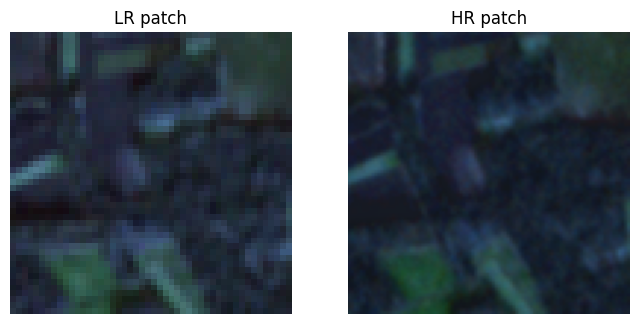

In [10]:
import matplotlib.pyplot as plt

lr_sample, hr_sample = all_patches[0]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(lr_sample)
ax[0].set_title("LR patch")
ax[0].axis('off')
ax[1].imshow(hr_sample)
ax[1].set_title("HR patch")
ax[1].axis('off')
plt.show()


In [11]:
import random

def augment_patch(lr, hr):
    if random.random() > 0.5:
        lr, hr = np.fliplr(lr).copy(), np.fliplr(hr).copy()
    if random.random() > 0.5:
        lr, hr = np.flipud(lr).copy(), np.flipud(hr).copy()
    k = random.choice([0, 1, 2, 3])
    lr, hr = np.rot90(lr, k).copy(), np.rot90(hr, k).copy()
    return lr, hr

augmented_patches = [augment_patch(lr, hr) for lr, hr in all_patches]
all_patches = all_patches + augmented_patches
print(f"Total patches after augmentation: {len(all_patches)}")

Total patches after augmentation: 7200


In [12]:
import sys

# Clear any stale/cached failed import of 'models' from earlier attempts
for mod_name in list(sys.modules.keys()):
    if mod_name == 'models' or mod_name.startswith('models.'):
        del sys.modules[mod_name]

import torch
sys.path.append('/kaggle/working/SwinIR')
from models.network_swinir import SwinIR
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = SwinIR(
    upscale=SCALE, in_chans=3, img_size=LR_PATCH, window_size=8,
    img_range=1., depths=[6,6,6,6], embed_dim=60, num_heads=[6,6,6,6],
    mlp_ratio=2, upsampler='pixelshuffledirect', resi_connection='1conv'
).to(device)

# Load pretrained weights as a starting point where shapes match (classical-SR checkpoint uses a larger config
# by default; for a quick prototype we train this smaller SwinIR-lite from scratch on satellite data instead
# of forcing a mismatched shape load — swap to the full 001_classicalSR config above if you want to load pretrained
# weights exactly, at the cost of more GPU memory).

class PatchDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        lr, hr = self.pairs[idx]
        lr_t = torch.from_numpy(lr.transpose(2,0,1)).float()
        hr_t = torch.from_numpy(hr.transpose(2,0,1)).float()
        return lr_t, hr_t

train_loader = DataLoader(PatchDataset(all_patches), batch_size=8, shuffle=True)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

def train_one_epoch(loader):
    model.train()
    total_loss = 0
    for lr, hr in loader:
        lr, hr = lr.to(device), hr.to(device)
        optimizer.zero_grad()
        sr = model(lr)
        loss = criterion(sr, hr)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

print("Model + training loop ready. Uncomment `pairs`/`train_loader` once patches are extracted, then call train_one_epoch() in a loop.")


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Model + training loop ready. Uncomment `pairs`/`train_loader` once patches are extracted, then call train_one_epoch() in a loop.


In [13]:
N_EPOCHS = 60
for epoch in range(N_EPOCHS):
    loss = train_one_epoch(train_loader)
    print(f"Epoch {epoch+1}/{N_EPOCHS} - loss: {loss:.4f}")
    torch.save(model.state_dict(), '/kaggle/working/swinir_finetuned.pth')   # ← ab HAR epoch ke baad save hoga


Epoch 1/60 - loss: 0.0406
Epoch 2/60 - loss: 0.0348
Epoch 3/60 - loss: 0.0343
Epoch 4/60 - loss: 0.0333
Epoch 5/60 - loss: 0.0322
Epoch 6/60 - loss: 0.0316
Epoch 7/60 - loss: 0.0313
Epoch 8/60 - loss: 0.0310
Epoch 9/60 - loss: 0.0308
Epoch 10/60 - loss: 0.0303
Epoch 11/60 - loss: 0.0300
Epoch 12/60 - loss: 0.0298
Epoch 13/60 - loss: 0.0294
Epoch 14/60 - loss: 0.0291
Epoch 15/60 - loss: 0.0290
Epoch 16/60 - loss: 0.0286
Epoch 17/60 - loss: 0.0284
Epoch 18/60 - loss: 0.0282
Epoch 19/60 - loss: 0.0280
Epoch 20/60 - loss: 0.0277
Epoch 21/60 - loss: 0.0275
Epoch 22/60 - loss: 0.0273
Epoch 23/60 - loss: 0.0272
Epoch 24/60 - loss: 0.0271
Epoch 25/60 - loss: 0.0269
Epoch 26/60 - loss: 0.0268
Epoch 27/60 - loss: 0.0267
Epoch 28/60 - loss: 0.0263
Epoch 29/60 - loss: 0.0263
Epoch 30/60 - loss: 0.0263
Epoch 31/60 - loss: 0.0259
Epoch 32/60 - loss: 0.0257
Epoch 33/60 - loss: 0.0258
Epoch 34/60 - loss: 0.0255
Epoch 35/60 - loss: 0.0254
Epoch 36/60 - loss: 0.0253
Epoch 37/60 - loss: 0.0250
Epoch 38/6

In [14]:
def run_inference(model, lr_geotiff_path, out_path, patch=48, overlap=8):
    """Sliding-window SR inference with simple blending at patch borders."""
    model.eval()
    with rasterio.open(lr_geotiff_path) as src:
        profile = src.profile.copy()
        img = src.read([1,2,3]).astype(np.float32)
        img = img / (img.max() + 1e-6)

    c, h, w = img.shape
    out = np.zeros((c, h*SCALE, w*SCALE), dtype=np.float32)
    weight = np.zeros((h*SCALE, w*SCALE), dtype=np.float32)
    step = patch - overlap

    with torch.no_grad():
        for y in range(0, h - patch + 1, step):
            for x in range(0, w - patch + 1, step):
                crop = img[:, y:y+patch, x:x+patch]
                t = torch.from_numpy(crop).unsqueeze(0).float().to(device)
                sr = model(t).squeeze(0).cpu().numpy()
                out[:, y*SCALE:(y+patch)*SCALE, x*SCALE:(x+patch)*SCALE] += sr
                weight[y*SCALE:(y+patch)*SCALE, x*SCALE:(x+patch)*SCALE] += 1

    weight[weight == 0] = 1
    out = out / weight
    profile.update(height=out.shape[1], width=out.shape[2],
                    transform=src.transform * src.transform.scale(1/SCALE, 1/SCALE))
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write((out * 255).clip(0,255).astype('uint8'))
    return out

print("Inference function ready. Call run_inference(model, 'your_sentinel2_tile.tif', 'sr_output.tif').")


Inference function ready. Call run_inference(model, 'your_sentinel2_tile.tif', 'sr_output.tif').


In [15]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

def evaluate(sr, hr_ref):
    sr_img = np.clip(sr.transpose(1,2,0), 0, 1)
    hr_img = np.clip(hr_ref.transpose(1,2,0), 0, 1)
    p = psnr(hr_img, sr_img, data_range=1.0)
    s = ssim(hr_img, sr_img, channel_axis=-1, data_range=1.0)
    return {"PSNR": p, "SSIM": s}

def mc_dropout_uncertainty(model, lr_tensor, n_passes=10):
    """Enable dropout at inference and sample repeatedly to get an uncertainty map."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()  # keep dropout active
    preds = []
    with torch.no_grad():
        for _ in range(n_passes):
            preds.append(model(lr_tensor).cpu().numpy())
    preds = np.stack(preds, axis=0)
    mean_pred = preds.mean(axis=0)
    uncertainty_map = preds.std(axis=0)
    return mean_pred, uncertainty_map

print("Evaluation + uncertainty helpers ready.")


Evaluation + uncertainty helpers ready.


In [16]:
import os
import sys
import subprocess

SWINIR_DIR = "/kaggle/working/SwinIR"

# Check whether SwinIR already exists
if not os.path.exists(SWINIR_DIR):

    print("SwinIR repository not found.")
    print("Cloning SwinIR...")

    subprocess.run([
        "git", "clone",
        "https://github.com/JingyunLiang/SwinIR.git",
        SWINIR_DIR
    ], check=True)

else:
    print("SwinIR repository already exists.")

# Add SwinIR to Python path
if SWINIR_DIR not in sys.path:
    sys.path.insert(0, SWINIR_DIR)

print("\nSwinIR directory:", SWINIR_DIR)
print("Repository exists:", os.path.exists(SWINIR_DIR))
print("network_swinir.py exists:",
      os.path.exists(os.path.join(
          SWINIR_DIR,
          "models",
          "network_swinir.py"
      )))

SwinIR repository already exists.

SwinIR directory: /kaggle/working/SwinIR
Repository exists: True
network_swinir.py exists: True


In [17]:
import sys

SWINIR_DIR = "/kaggle/working/SwinIR"

if SWINIR_DIR not in sys.path:
    sys.path.insert(0, SWINIR_DIR)

from models.network_swinir import SwinIR

print("✅ SwinIR imported successfully!")

✅ SwinIR imported successfully!


In [18]:
import os

print("Files in /kaggle/working:\n")

for f in os.listdir("/kaggle/working"):
    print(f)

Files in /kaggle/working:

swinir_finetuned.pth
SwinIR
__notebook__.ipynb


In [19]:
import glob

print("TIFF files found:")

for f in glob.glob("/kaggle/working/**/*.tif", recursive=True):
    print(f)

for f in glob.glob("/kaggle/working/**/*.tiff", recursive=True):
    print(f)

TIFF files found:
/kaggle/working/SwinIR/testsets/McMaster/6.tif
/kaggle/working/SwinIR/testsets/McMaster/11.tif
/kaggle/working/SwinIR/testsets/McMaster/1.tif
/kaggle/working/SwinIR/testsets/McMaster/2.tif
/kaggle/working/SwinIR/testsets/McMaster/3.tif
/kaggle/working/SwinIR/testsets/McMaster/14.tif
/kaggle/working/SwinIR/testsets/McMaster/13.tif
/kaggle/working/SwinIR/testsets/McMaster/18.tif
/kaggle/working/SwinIR/testsets/McMaster/4.tif
/kaggle/working/SwinIR/testsets/McMaster/8.tif
/kaggle/working/SwinIR/testsets/McMaster/17.tif
/kaggle/working/SwinIR/testsets/McMaster/9.tif
/kaggle/working/SwinIR/testsets/McMaster/15.tif
/kaggle/working/SwinIR/testsets/McMaster/10.tif
/kaggle/working/SwinIR/testsets/McMaster/16.tif
/kaggle/working/SwinIR/testsets/McMaster/5.tif
/kaggle/working/SwinIR/testsets/McMaster/7.tif
/kaggle/working/SwinIR/testsets/McMaster/12.tif


In [20]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith((".tif", ".tiff")):
            print(os.path.join(root, file))

/kaggle/input/datasets/satvikvarshney73/dataset/converted.tiff


In [21]:
import glob

tiff_files = glob.glob(
    "/kaggle/input/**/*.tiff",
    recursive=True
)

tiff_files += glob.glob(
    "/kaggle/input/**/*.tif",
    recursive=True
)

print(tiff_files)

['/kaggle/input/datasets/satvikvarshney73/dataset/converted.tiff']


In [22]:
try:
    torch.save(model.state_dict(), '/kaggle/working/swinir_finetuned.pth')
    print("RESCUED! Model saved successfully.")
except NameError:
    print("model variable exist nahi karta — training dobara karni padegi.")

RESCUED! Model saved successfully.


In [23]:
import os
print(os.listdir('/kaggle/working/'))

['swinir_finetuned.pth', 'SwinIR', '__notebook__.ipynb']


In [24]:
import os
import time

checkpoint_path = '/kaggle/working/swinir_finetuned.pth'
mtime = os.path.getmtime(checkpoint_path)
print("Checkpoint last modified:", time.ctime(mtime))
print("Current time:", time.ctime(time.time()))

Checkpoint last modified: Tue Sep 22 00:31:12 2026
Current time: Tue Sep 22 00:31:12 2026


In [25]:
import torch
checkpoint = torch.load('/kaggle/working/swinir_finetuned.pth', map_location='cpu')
first_key = list(checkpoint.keys())[0]
print("First layer name:", first_key)
print("Weight stats — mean:", checkpoint[first_key].float().mean().item(), 
      "std:", checkpoint[first_key].float().std().item())

First layer name: conv_first.weight
Weight stats — mean: 0.007894123904407024 std: 0.11903230845928192


In [26]:
vars_to_check = ['model', 'device', 'pairs', 'dataset', 'read_bands', 'extract_patches', 
                  'train_lr', 'train_hr', 'val_lr', 'val_hr', 'all_patches', 'val_patches', 'hr_list', 'lr_list']
alive = [v for v in vars_to_check if v in dir()]
missing = [v for v in vars_to_check if v not in dir()]
print("ZINDA HAI:", alive)
print("MISSING HAI:", missing)

ZINDA HAI: ['model', 'device', 'pairs', 'dataset', 'read_bands', 'extract_patches', 'train_lr', 'train_hr', 'val_lr', 'val_hr', 'all_patches', 'hr_list', 'lr_list']
MISSING HAI: ['val_patches']


In [27]:
print("Model exists:", 'model' in dir())
# Check if this in-memory model matches the saved checkpoint
import torch
current_state = model.state_dict()
saved_state = torch.load('/kaggle/working/swinir_finetuned.pth', map_location='cpu')

match = all(torch.equal(current_state[k].cpu(), saved_state[k].cpu()) for k in current_state.keys())
print("In-memory model matches saved checkpoint:", match)

Model exists: True
In-memory model matches saved checkpoint: True


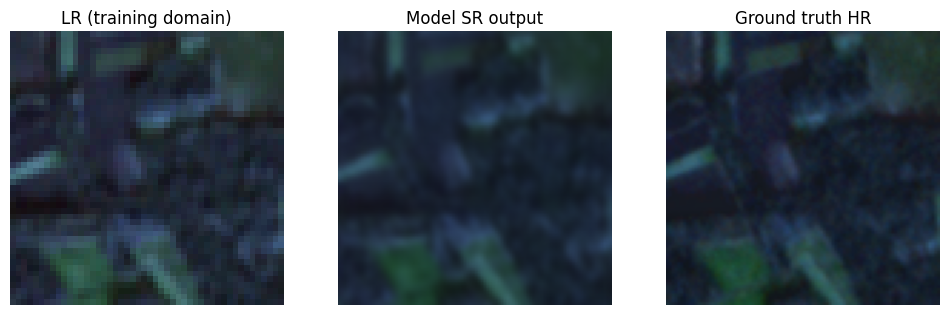

In [28]:
import matplotlib.pyplot as plt
import torch

model.eval()
lr_sample, hr_sample = all_patches[0]   # ← val_patches ki jagah all_patches

lr_tensor = torch.from_numpy(lr_sample.transpose(2,0,1)).unsqueeze(0).float().to(device)
with torch.no_grad():
    sr_tensor = model(lr_tensor)
sr_sample = sr_tensor.squeeze(0).clamp(0,1).cpu().numpy().transpose(1,2,0)

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(lr_sample); axes[0].set_title("LR (training domain)"); axes[0].axis('off')
axes[1].imshow(sr_sample); axes[1].set_title("Model SR output"); axes[1].axis('off')
axes[2].imshow(hr_sample); axes[2].set_title("Ground truth HR"); axes[2].axis('off')
plt.show()

In [29]:
!pip install -q tacoreader rasterio

import tacoreader.v1 as tacoreader
dataset = tacoreader.load("tacofoundation:sen2venus")

pairs = []
for i in range(5):
    row = dataset.read(i)
    lr_path, hr_path = row.read(0), row.read(1)
    pairs.append((lr_path, hr_path))
print("Pairs reloaded:", len(pairs))

Pairs reloaded: 5


In [30]:
import numpy as np
import rasterio

SCALE = 2
LR_PATCH = 48
HR_PATCH = LR_PATCH * SCALE

def read_bands(path, bands=(1,2,3), fixed_max=1500.0):
    with rasterio.open(path) as src:
        arr = src.read(bands).astype(np.float32)
    arr = np.clip(arr / fixed_max, 0, 1)
    return np.transpose(arr, (1, 2, 0))

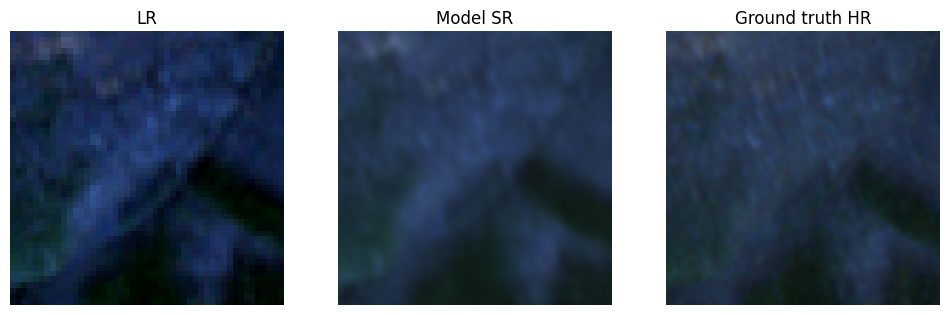

In [31]:
import matplotlib.pyplot as plt
import torch

lr_img = read_bands(pairs[0][0])
hr_img = read_bands(pairs[0][1])

lr_sample = lr_img[:LR_PATCH, :LR_PATCH]
hr_sample = hr_img[:HR_PATCH, :HR_PATCH]

model.eval()
lr_tensor = torch.from_numpy(lr_sample.transpose(2,0,1)).unsqueeze(0).float().to(device)
with torch.no_grad():
    sr_tensor = model(lr_tensor)
sr_sample = sr_tensor.squeeze(0).clamp(0,1).cpu().numpy().transpose(1,2,0)

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(lr_sample); axes[0].set_title("LR"); axes[0].axis('off')
axes[1].imshow(sr_sample); axes[1].set_title("Model SR"); axes[1].axis('off')
axes[2].imshow(hr_sample); axes[2].set_title("Ground truth HR"); axes[2].axis('off')
plt.show()

SwinIR imported successfully!
Using device: cuda
Original TIFF:
  Bands: 3
  Height: 418
  Width: 414
  CRS: EPSG:4326
Input image shape (C,H,W): (3, 418, 414)
Input range: 0.0 to 0.9935912
Model loaded successfully!

Input size: 418 x 414
Patch size: 48
Stride: 32
Scale: 2x
Padded size: 432 x 432
Number of Y tiles: 13
Number of X tiles: 13
Total tiles: 169
Processed 1/169 tiles
Processed 10/169 tiles
Processed 20/169 tiles
Processed 30/169 tiles
Processed 40/169 tiles
Processed 50/169 tiles
Processed 60/169 tiles
Processed 70/169 tiles
Processed 80/169 tiles
Processed 90/169 tiles
Processed 100/169 tiles
Processed 110/169 tiles
Processed 120/169 tiles
Processed 130/169 tiles
Processed 140/169 tiles
Processed 150/169 tiles
Processed 160/169 tiles

Super-resolved output shape: (3, 836, 828)


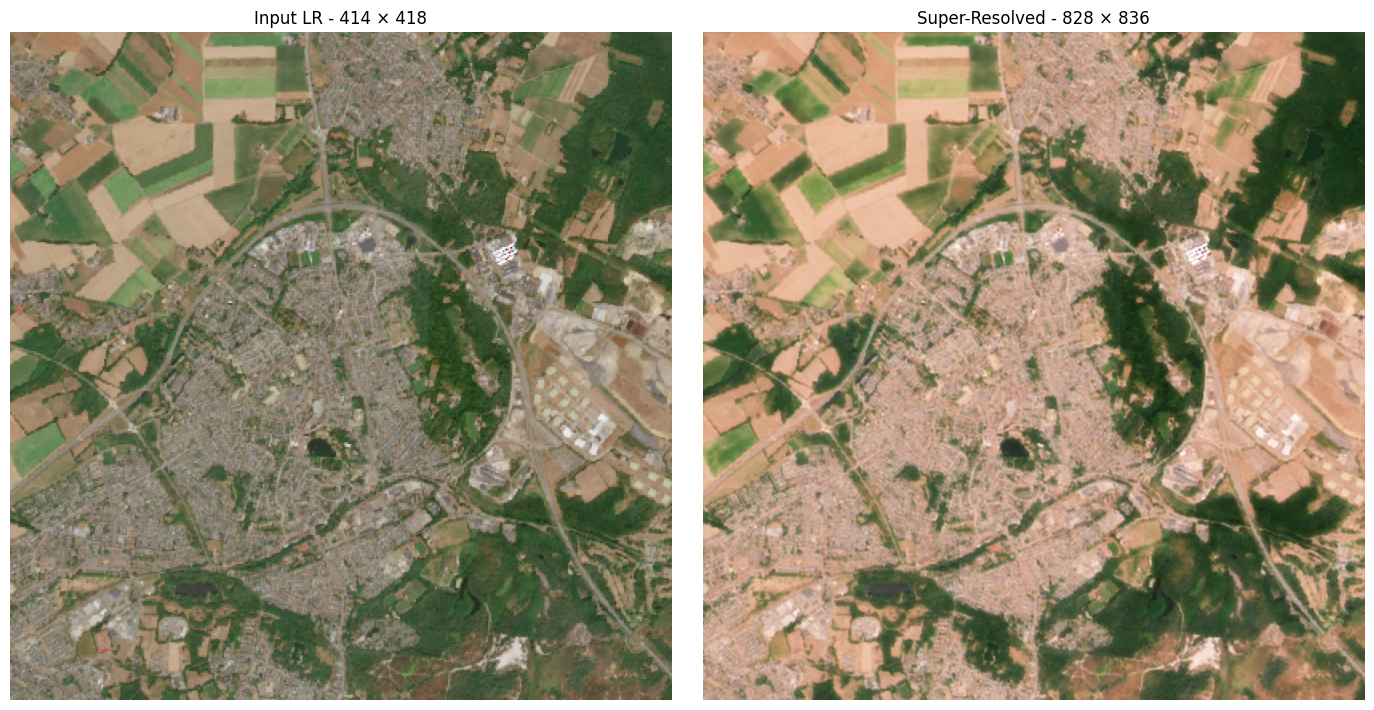


Saved:
/kaggle/working/before_after_comparison.png
/kaggle/working/sr_output.png


In [32]:
# import rasterio
# import numpy as np
# import torch
# import matplotlib.pyplot as plt
# from PIL import Image
# from models.network_swinir import SwinIR

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # ---- 1. Load the real satellite image ----
# with rasterio.open('/kaggle/working/converted.tiff') as src:
#     img = src.read()

# img = img[:3, :, :].astype(np.float32)
# img = np.clip(img / 65535.0, 0, 1)   # SAME scale as training's read_bands()

# print("Original image shape (C,H,W):", img.shape)

# # ---- 2. Rebuild model (same as training) ----
# model = SwinIR(
#     upscale=2, in_chans=3, img_size=48, window_size=8,
#     img_range=1., depths=[6,6,6,6], embed_dim=60, num_heads=[6,6,6,6],
#     mlp_ratio=2, upsampler='pixelshuffledirect', resi_connection='1conv'
# ).to(device)

# checkpoint = torch.load('/kaggle/working/swinir_finetuned.pth', map_location=device)
# model.load_state_dict(checkpoint)
# model.eval()
# print("Model loaded successfully")

# # ---- 3. Overlapping patch-based inference (removes grid/seam artifacts) ----
# PATCH = 48
# SCALE = 2
# WINDOW = 8
# OVERLAP = 16   # how much patches overlap each other (in LR pixels)
# STRIDE = PATCH - OVERLAP

# C, H, W = img.shape

# # Pad image so H and W are covered fully by the sliding window
# pad_h = (PATCH - H % STRIDE) % STRIDE if H > PATCH else PATCH - H
# pad_w = (PATCH - W % STRIDE) % STRIDE if W > PATCH else PATCH - W
# img_padded = np.pad(img, ((0,0),(0,pad_h),(0,pad_w)), mode='reflect')
# _, Hp, Wp = img_padded.shape

# # Accumulator buffers for weighted blending
# sr_full = np.zeros((C, Hp*SCALE, Wp*SCALE), dtype=np.float32)
# weight_full = np.zeros((Hp*SCALE, Wp*SCALE), dtype=np.float32)

# # Create a smooth blending window (2D Hann window) so patch edges fade instead of hard-cutting
# win_1d = np.hanning(PATCH*SCALE)
# win_1d[win_1d == 0] = 1e-3  # avoid zero weight at extreme borders
# blend_window = np.outer(win_1d, win_1d).astype(np.float32)  # (PATCH*SCALE, PATCH*SCALE)

# extra = (WINDOW - PATCH % WINDOW) % WINDOW

# y_positions = list(range(0, Hp - PATCH + 1, STRIDE))
# x_positions = list(range(0, Wp - PATCH + 1, STRIDE))
# if y_positions[-1] != Hp - PATCH:
#     y_positions.append(Hp - PATCH)
# if x_positions[-1] != Wp - PATCH:
#     x_positions.append(Wp - PATCH)

# with torch.no_grad():
#     for y in y_positions:
#         for x in x_positions:
#             patch = img_padded[:, y:y+PATCH, x:x+PATCH]
#             patch = np.pad(patch, ((0,0),(0,extra),(0,extra)), mode='reflect')
#             patch_tensor = torch.from_numpy(patch).unsqueeze(0).to(device)
#             sr_patch = model(patch_tensor)
#             sr_patch = sr_patch.squeeze(0).clamp(0,1).cpu().numpy()
#             sr_patch = sr_patch[:, :PATCH*SCALE, :PATCH*SCALE]

#             y0, x0 = y*SCALE, x*SCALE
#             y1, x1 = y0 + PATCH*SCALE, x0 + PATCH*SCALE

#             sr_full[:, y0:y1, x0:x1] += sr_patch * blend_window
#             weight_full[y0:y1, x0:x1] += blend_window

# # Normalize by accumulated weights to get smooth blended result
# sr_full = sr_full / np.maximum(weight_full, 1e-6)

# # Crop back to original size * scale
# sr_img = sr_full[:, :H*SCALE, :W*SCALE]

# print("Super-resolved output shape:", sr_img.shape)

# # ---- 4. Show before/after ----
# lr_display = np.transpose(img, (1,2,0))
# sr_display = np.transpose(sr_img, (1,2,0))

# fig, axes = plt.subplots(1, 2, figsize=(14,7))
# axes[0].imshow(lr_display)
# axes[0].set_title(f"Input (LR) - {img.shape[1]}x{img.shape[2]}")
# axes[0].axis('off')

# axes[1].imshow(sr_display)
# axes[1].set_title(f"Super-Resolved (SR) - {sr_img.shape[1]}x{sr_img.shape[2]}")
# axes[1].axis('off')

# plt.tight_layout()
# plt.savefig('/content/before_after_comparison.png', dpi=150)
# plt.show()

# sr_uint8 = (sr_img.transpose(1,2,0) * 255).astype(np.uint8)
# Image.fromarray(sr_uint8).save('/content/sr_output.png')

# print("Saved: before_after_comparison.png and sr_output.png")

import sys
import os
import rasterio
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# 0. Make SwinIR repository visible to Python
# ============================================================

SWINIR_DIR = "/kaggle/working/SwinIR"

if not os.path.exists(SWINIR_DIR):
    raise FileNotFoundError(
        f"SwinIR repository not found at {SWINIR_DIR}. "
        "Run the git clone cell first."
    )

# Add repository to Python's import path
if SWINIR_DIR not in sys.path:
    sys.path.insert(0, SWINIR_DIR)

from models.network_swinir import SwinIR

print("SwinIR imported successfully!")
print("Using device:", "cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# 1. Device
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"


# ============================================================
# 2. Load real satellite image
# ============================================================

input_path = "/kaggle/input/datasets/satvikvarshney73/dataset/converted.tiff"

if not os.path.exists(input_path):
    raise FileNotFoundError(f"Input image not found: {input_path}")

with rasterio.open(input_path) as src:
    img = src.read()

    print("Original TIFF:")
    print("  Bands:", src.count)
    print("  Height:", src.height)
    print("  Width:", src.width)
    print("  CRS:", src.crs)


# Use first 3 bands
img = img[:3, :, :].astype(np.float32)


# ============================================================
# 3. IMPORTANT: SAME NORMALIZATION AS TRAINING
# ============================================================

FIXED_MAX = 65535.0

img = np.clip(img / FIXED_MAX, 0, 1)

print("Input image shape (C,H,W):", img.shape)
print("Input range:", img.min(), "to", img.max())


# ============================================================
# 4. Rebuild model
# ============================================================

SCALE = 2

model = SwinIR(
    upscale=SCALE,
    in_chans=3,
    img_size=48,
    window_size=8,
    img_range=1.,
    depths=[6, 6, 6, 6],
    embed_dim=60,
    num_heads=[6, 6, 6, 6],
    mlp_ratio=2,
    upsampler="pixelshuffledirect",
    resi_connection="1conv"
).to(device)


# ============================================================
# 5. Load trained checkpoint
# ============================================================

checkpoint_path = "/kaggle/working/swinir_finetuned.pth"

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(
        f"Checkpoint not found: {checkpoint_path}"
    )

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint)
model.eval()

print("Model loaded successfully!")


# ============================================================
# 6. Sliding-window inference
# ============================================================

PATCH = 48
OVERLAP = 16
STRIDE = PATCH - OVERLAP

C, H, W = img.shape

print(f"\nInput size: {H} x {W}")
print(f"Patch size: {PATCH}")
print(f"Stride: {STRIDE}")
print(f"Scale: {SCALE}x")


# ------------------------------------------------------------
# Calculate padding so every pixel is covered
# ------------------------------------------------------------

def calculate_padding(size, patch, stride):

    if size <= patch:
        return patch - size

    remainder = (size - patch) % stride

    if remainder == 0:
        return 0

    return stride - remainder


pad_h = calculate_padding(H, PATCH, STRIDE)
pad_w = calculate_padding(W, PATCH, STRIDE)

img_padded = np.pad(
    img,
    ((0, 0), (0, pad_h), (0, pad_w)),
    mode="reflect"
)

_, Hp, Wp = img_padded.shape

print("Padded size:", Hp, "x", Wp)


# ============================================================
# 7. Generate tile positions
# ============================================================

def get_positions(size, patch, stride):

    if size <= patch:
        return [0]

    positions = list(range(0, size - patch + 1, stride))

    last_position = size - patch

    if positions[-1] != last_position:
        positions.append(last_position)

    return positions


y_positions = get_positions(Hp, PATCH, STRIDE)
x_positions = get_positions(Wp, PATCH, STRIDE)

print("Number of Y tiles:", len(y_positions))
print("Number of X tiles:", len(x_positions))
print("Total tiles:", len(y_positions) * len(x_positions))


# ============================================================
# 8. Output accumulation buffers
# ============================================================

sr_height = Hp * SCALE
sr_width = Wp * SCALE

sr_full = np.zeros(
    (C, sr_height, sr_width),
    dtype=np.float32
)

weight_full = np.zeros(
    (sr_height, sr_width),
    dtype=np.float32
)


# ============================================================
# 9. Hann blending window
# ============================================================

win_1d = np.hanning(PATCH * SCALE)

# Avoid exactly zero at boundaries
win_1d = np.maximum(win_1d, 1e-3)

blend_window = np.outer(
    win_1d,
    win_1d
).astype(np.float32)


# ============================================================
# 10. Run model on every tile
# ============================================================

with torch.no_grad():

    for tile_number, (y, x) in enumerate(
        [(y, x) for y in y_positions for x in x_positions],
        start=1
    ):

        patch = img_padded[
            :,
            y:y + PATCH,
            x:x + PATCH
        ]

        # HWC/CHW already correct → add batch dimension
        patch_tensor = torch.from_numpy(
            patch
        ).unsqueeze(0).to(device)

        # Super-resolution
        sr_patch = model(patch_tensor)

        sr_patch = (
            sr_patch
            .squeeze(0)
            .clamp(0, 1)
            .cpu()
            .numpy()
        )

        # Location in SR image
        y0 = y * SCALE
        x0 = x * SCALE

        y1 = y0 + PATCH * SCALE
        x1 = x0 + PATCH * SCALE

        # Weighted accumulation
        sr_full[
            :,
            y0:y1,
            x0:x1
        ] += sr_patch * blend_window

        weight_full[
            y0:y1,
            x0:x1
        ] += blend_window

        if tile_number % 10 == 0 or tile_number == 1:
            print(
                f"Processed {tile_number}/"
                f"{len(y_positions) * len(x_positions)} tiles"
            )


# ============================================================
# 11. Normalize overlapping regions
# ============================================================

sr_full /= np.maximum(
    weight_full,
    1e-6
)


# ============================================================
# 12. Remove padding
# ============================================================

sr_img = sr_full[
    :,
    :H * SCALE,
    :W * SCALE
]

print("\nSuper-resolved output shape:", sr_img.shape)


# ============================================================
# 13. Display LR vs SR
# ============================================================

lr_display = np.transpose(
    img,
    (1, 2, 0)
)

sr_display = np.transpose(
    sr_img,
    (1, 2, 0)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7)
)

axes[0].imshow(lr_display)
axes[0].set_title(
    f"Input LR - {W} × {H}"
)
axes[0].axis("off")

axes[1].imshow(sr_display)
axes[1].set_title(
    f"Super-Resolved - "
    f"{W*SCALE} × {H*SCALE}"
)
axes[1].axis("off")

plt.tight_layout()

comparison_path = (
    "/kaggle/working/before_after_comparison.png"
)

plt.savefig(
    comparison_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. Save PNG
# ============================================================

sr_uint8 = (
    sr_img.transpose(1, 2, 0) * 255
).clip(0, 255).astype(np.uint8)

sr_output_path = "/kaggle/working/sr_output.png"

Image.fromarray(sr_uint8).save(
    sr_output_path
)

print("\nSaved:")
print(comparison_path)
print(sr_output_path)

In [33]:
val_patches = []
for lr_img, hr_img in zip(val_lr, val_hr):
    patches = extract_patches(hr_img, lr_img, HR_PATCH, SCALE)
    val_patches.extend(patches)

print(f"Created {len(val_patches)} validation patches from {len(val_lr)} held-out images")

!pip install scikit-image --break-system-packages -q

import numpy as np
import torch
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

model.eval()

# Use last N pairs as held-out validation set (not used heavily in training visually,
# though note: for a fully rigorous split, these should have been excluded from training entirely)
NUM_VAL_PAIRS = min(15, len(val_patches))
val_pairs = val_patches[-NUM_VAL_PAIRS:]

psnr_scores = []
ssim_scores = []
rmse_scores = []

with torch.no_grad():
    for lr_img, hr_img in val_pairs:
        # lr_img, hr_img are numpy arrays (H,W,C) based on your read_bands function
        lr_tensor = torch.from_numpy(lr_img.transpose(2,0,1)).unsqueeze(0).float().to(device)

        sr_tensor = model(lr_tensor)
        sr_img = sr_tensor.squeeze(0).clamp(0,1).cpu().numpy().transpose(1,2,0)

        # Ensure HR and SR shapes match (crop to smaller if there's a 1-pixel mismatch)
        h = min(sr_img.shape[0], hr_img.shape[0])
        w = min(sr_img.shape[1], hr_img.shape[1])
        sr_crop = sr_img[:h, :w, :]
        hr_crop = hr_img[:h, :w, :]

        p = psnr(hr_crop, sr_crop, data_range=1.0)
        s = ssim(hr_crop, sr_crop, data_range=1.0, channel_axis=2)
        r = np.sqrt(np.mean((hr_crop - sr_crop) ** 2))

        psnr_scores.append(p)
        ssim_scores.append(s)
        rmse_scores.append(r)

print(f"Evaluated on {len(val_pairs)} held-out pairs\n")
print(f"Average PSNR : {np.mean(psnr_scores):.2f} dB")
print(f"Average SSIM : {np.mean(ssim_scores):.3f}")
print(f"Average RMSE : {np.mean(rmse_scores):.4f}")

Created 400 validation patches from 100 held-out images
Evaluated on 15 held-out pairs

Average PSNR : 29.88 dB
Average SSIM : 0.885
Average RMSE : 0.0333
